<a href="https://colab.research.google.com/github/aditya-r21/Deep-Learning/blob/main/Audio_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
from torch import nn
from torch.optim import Adam
from torchsummary import summary
import librosa
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import time
from skimage.transform import resize

device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [ ]:
data = []
base_dir = "/content/toronto-emotional-speech-set-tess/TESS_Toronto_emotional_speech_set_data"

for class_name in os.listdir(base_dir):
  class_path = os.path.join(base_dir, class_name)
  if os.path.isdir(class_path):
    for file in os.listdir(class_path):
      if file.endswith(".wav"):
        file_path = os.path.join(class_path, file)
        data.append([file_path, class_name])

df = pd.DataFrame(data, columns=["file_path", "label"])
df.head()

,file_path,label
0,/content/toronto-emotional-speech-set-tess/TES...,YAF_sad
1,/content/toronto-emotional-speech-set-tess/TES...,YAF_sad
2,/content/toronto-emotional-speech-set-tess/TES...,YAF_sad
3,/content/toronto-emotional-speech-set-tess/TES...,YAF_sad
4,/content/toronto-emotional-speech-set-tess/TES...,YAF_sad


Data shape is:  (2800, 2) 

Class distribution is: 


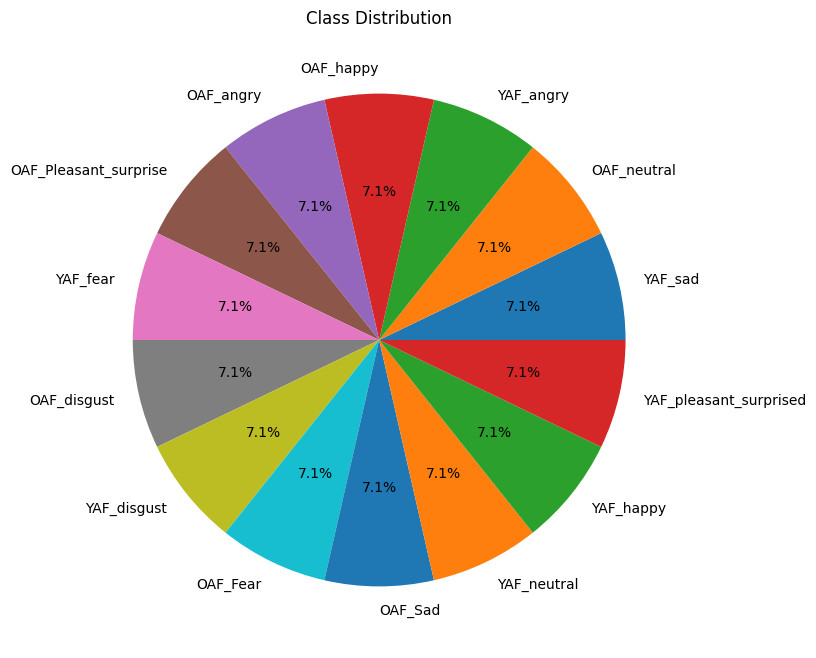

In [ ]:
print("Data shape is: ", df.shape, "\n")
print("Class distribution is: ")
class_counts = df['label'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(class_counts, labels = class_counts.index, autopct='%1.1f%%')
plt.title('Class Distribution')
plt.show()

In [ ]:
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['label'])

train, test = train_test_split(df, test_size = 0.3, stratify = df['label'], random_state = 42)

val, test = train_test_split(test, test_size = 0.5, stratify = test['label'], random_state = 42)

print("Training Shape: ", train.shape)
print("Validation Shape: ", val.shape)
print("Testing Shape: ", test.shape)

Training Shape:  (1960, 2)
Validation Shape:  (420, 2)
Testing Shape:  (420, 2)


In [ ]:
class CustomAudioDataset(Dataset):
  def __init__(self, dataframe):
    self.dataframe = dataframe
    self.labels = torch.Tensor(list(dataframe['label'])).type(torch.LongTensor).to(device)
    self.audios = [torch.Tensor(self.get_spectrogram(path)).type(torch.FloatTensor) for path in dataframe['file_path']]

  def __len__(self):
    return self.dataframe.shape[0]

  def __getitem__(self, idx):
    img_path = self.dataframe.iloc[idx, 0]
    label = torch.Tensor(self.labels[idx]).to(device)
    audio = (self.audios[idx]).unsqueeze(0).to(device)
    return audio, label

  def get_spectrogram(self, file_path):
    sr = 22050
    duration = 5
    img_height = 128
    img_width = 256
    signal, sr = librosa.load(file_path, sr = 22050, duration = duration)
    spectrogram = librosa.feature.melspectrogram(y = signal, sr = sr, n_fft = 2048, hop_length = 512, n_mels = 128)
    spec_db = librosa.power_to_db(spectrogram, ref = np.max)
    spec_resized = librosa.util.fix_length(spec_db, size = duration * sr // 512 + 1)
    spec_resized = resize(spec_resized, (img_height, img_width), anti_aliasing = True)
    return spec_resized

In [ ]:
train_dataset = CustomAudioDataset(dataframe = train)
val_dataset = CustomAudioDataset(dataframe = val)
test_dataset = CustomAudioDataset(dataframe = test)

In [ ]:
LR = 1e-4
BATCH_SIZE = 16
EPOCHS = 25

In [ ]:
train_loader = DataLoader(train_dataset, batch_size = BATCH_SIZE, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size = BATCH_SIZE, shuffle = False)
test_loader = DataLoader(test_dataset, batch_size = BATCH_SIZE, shuffle = False)

In [ ]:
class Net(nn.Module):
  def __init__(self):
    super().__init__()

    self.conv1 = nn.Conv2d(1, 16, kernel_size = 3, padding = 1)
    self.conv2 = nn.Conv2d(16, 32, kernel_size = 3, stride = 1, padding = 1)
    self.conv3 = nn.Conv2d(32, 64, kernel_size = 3, stride = 1, padding = 1)
    self.pooling = nn.MaxPool2d(2, 2)
    self.relu = nn.ReLU()

    self.flatten = nn.Flatten()
    self.linear1 = nn.Linear((64 * 16 * 32), 4096)
    self.linear2 = nn.Linear(4096, 1024)
    self.linear3 = nn.Linear(1024, 512)
    self.output = nn.Linear(512, len(df['label'].unique()))

    self.dropout = nn.Dropout(0.5)

  def forward(self, x):
    x = self.conv1(x) # -> Outputs: (16, (128, 256))
    x = self.pooling(x)# -> Outputs: (16, (64, 128))
    x = self.relu(x)
    x = self.dropout(x)
    x = self.conv2(x) # -> Outputs: (32, (64, 128))
    x = self.pooling(x) # -> Outputs: (32, (32, 64))
    x = self.relu(x)
    x = self.dropout(x)
    x = self.conv3(x) # -> Outputs: (64, (32, 64))
    x = self.pooling(x) # -> Outputs: (64, (16, 32))
    x = self.relu(x)
    x = self.dropout(x)
    x = x.view(x.size(0), -1)

    x = self.flatten(x)

    x = self.linear1(x)
    x = self.dropout(x)

    x = self.linear2(x)
    x = self.dropout(x)


    x = self.linear3(x)
    x = self.dropout(x)

    x = self.output(x)

    return x

model = Net().to(device)
print(model)

Net(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pooling): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear1): Linear(in_features=32768, out_features=4096, bias=True)
  (linear2): Linear(in_features=4096, out_features=1024, bias=True)
  (linear3): Linear(in_features=1024, out_features=512, bias=True)
  (output): Linear(in_features=512, out_features=14, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)


In [ ]:
summary(model, (1, 128, 256))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 16, 128, 256]             160
         MaxPool2d-2          [-1, 16, 64, 128]               0
              ReLU-3          [-1, 16, 64, 128]               0
           Dropout-4          [-1, 16, 64, 128]               0
            Conv2d-5          [-1, 32, 64, 128]           4,640
         MaxPool2d-6           [-1, 32, 32, 64]               0
              ReLU-7           [-1, 32, 32, 64]               0
           Dropout-8           [-1, 32, 32, 64]               0
            Conv2d-9           [-1, 64, 32, 64]          18,496
        MaxPool2d-10           [-1, 64, 16, 32]               0
             ReLU-11           [-1, 64, 16, 32]               0
          Dropout-12           [-1, 64, 16, 32]               0
          Flatten-13                [-1, 32768]               0
           Linear-14                 [-

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr = LR)

In [ ]:
total_loss_train_plot = []
total_loss_val_plot = []
total_acc_train_plot = []
total_acc_val_plot = []

for epoch in range(EPOCHS):
  start_time = time.time()
  total_acc_train = 0
  total_loss_train = 0
  total_acc_val = 0
  total_loss_val = 0

  for inputs, labels in train_loader:
    outputs = model(inputs)
    train_loss = criterion(outputs, labels)
    total_loss_train += train_loss.item()
    train_loss.backward()

    train_acc = (torch.argmax(outputs, axis = 1) == labels).sum().item()
    total_acc_train += train_acc
    optimizer.step()
    optimizer.zero_grad()

  with torch.no_grad():
    for inputs, labels in val_loader:
      outputs = model(inputs)
      val_loss = criterion(outputs, labels)
      total_loss_val += val_loss.item()

      val_acc = (torch.argmax(outputs, axis = 1) == labels).sum().item()
      total_acc_val += val_acc

  total_loss_train_plot.append(round(total_loss_train/1000, 4))
  total_loss_val_plot.append(round(total_loss_val/1000, 4))
  total_acc_train_plot.append(round(total_acc_train/(train_dataset.__len__())*100, 4))
  total_acc_val_plot.append(round(total_acc_val/(val_dataset.__len__())*100, 4))
  epoch_string = f"""Epoch: {epoch+1}/{EPOCHS}, Train Loss: {round(total_loss_train/100, 4)}, Train Accuracy: {round((total_acc_train/train_dataset.__len__() * 100), 4)}, Validation Loss: {round(total_loss_val/100, 4)}, Validation Accuracy: {round((total_acc_val/val_dataset.__len__() * 100), 4)}
                  """
  print(epoch_string)

Epoch: 1/25, Train Loss: 15.5027, Train Accuracy: 19.3367, Validation Loss: 0.6255, Validation Accuracy: 22.381
                  
Epoch: 2/25, Train Loss: 2.5755, Train Accuracy: 26.3265, Validation Loss: 0.5515, Validation Accuracy: 27.1429
                  
Epoch: 3/25, Train Loss: 2.3986, Train Accuracy: 27.8571, Validation Loss: 0.5165, Validation Accuracy: 29.7619
                  
Epoch: 4/25, Train Loss: 2.3508, Train Accuracy: 28.7245, Validation Loss: 0.5264, Validation Accuracy: 28.3333
                  
Epoch: 5/25, Train Loss: 2.3128, Train Accuracy: 29.5408, Validation Loss: 0.5106, Validation Accuracy: 26.9048
                  
Epoch: 6/25, Train Loss: 2.2218, Train Accuracy: 32.1429, Validation Loss: 0.5068, Validation Accuracy: 31.1905
                  
Epoch: 7/25, Train Loss: 2.1809, Train Accuracy: 34.5918, Validation Loss: 0.4751, Validation Accuracy: 37.381
                  
Epoch: 8/25, Train Loss: 2.1041, Train Accuracy: 38.5204, Validation Loss: 0.4498, V

In [ ]:
with torch.no_grad():
  total_loss_test = 0
  total_acc_test = 0
  for indx, (input, labels) in enumerate(test_loader):

    prediction = model(input)

    acc = (torch.argmax(prediction, axis = 1) == labels).sum().item()
    total_acc_test += acc

print(f"Accuracy Score is: {round((total_acc_test/test_dataset.__len__())*100, 2)}%")

Accuracy Score is: 91.9%


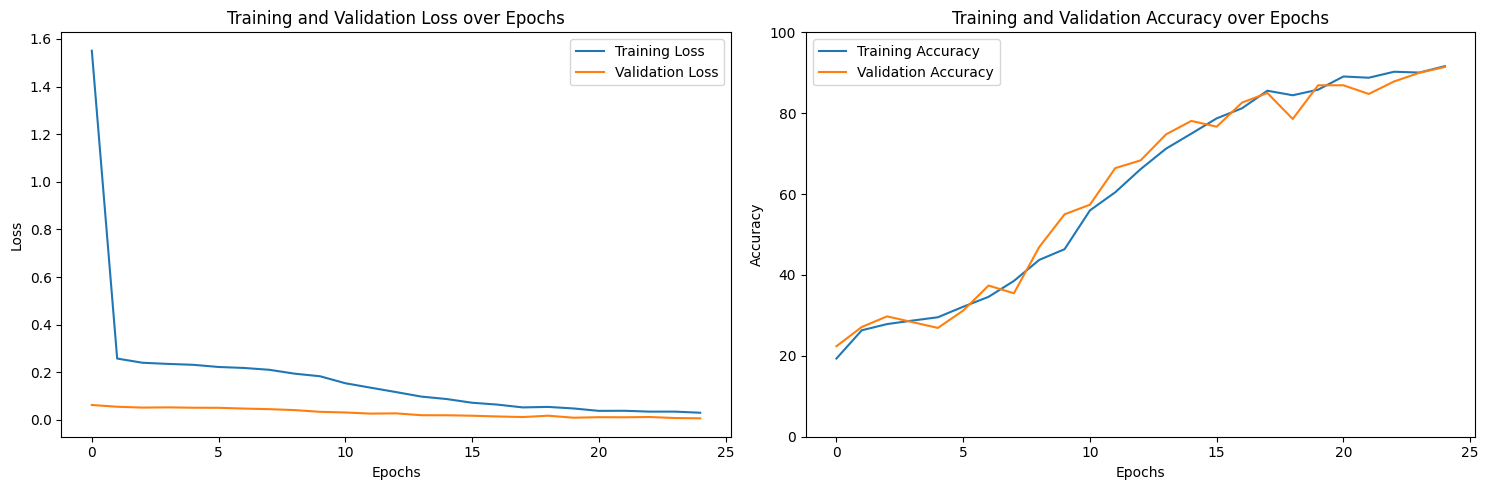

In [ ]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

axs[0].plot(total_loss_train_plot, label='Training Loss')
axs[0].plot(total_loss_val_plot, label='Validation Loss')
axs[0].set_title('Training and Validation Loss over Epochs')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[1].set_ylim([0, 2])
axs[0].legend()

axs[1].plot(total_acc_train_plot, label='Training Accuracy')
axs[1].plot(total_acc_val_plot, label='Validation Accuracy')
axs[1].set_title('Training and Validation Accuracy over Epochs')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].set_ylim([0, 100])
axs[1].legend()

plt.tight_layout()

plt.show()